# SPX Options — Implied Volatility & Variance Risk Premium
### Econometrics Project · Politecnico di Milano

**Research questions**
1. Does implied volatility predict realized volatility? *(linear regression)*
2. Does the skew add incremental predictive power? *(multivariate regression)*
3. Is there a persistent Variance Risk Premium? *(VRP = IV − RV)*

**Dataset** · One-year S&P 500 options (08 Jun 2017 → 08 Jun 2018)  
**Methods covered** · OLS, Fixed Effects, ARMA, VAR, GARCH, Cointegration, PCA

---


## 0 · Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
RISK_FREE     = 0.02            # constant risk-free rate (US 1Y T-bill ~2% in 2017-18)
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("✓ Libraries loaded")


✓ Libraries loaded


## 1 · Black-Scholes pricing & implied volatility

### 1.1 Theoretical background

The **Black-Scholes** formula prices a European option under the assumptions of:
- Log-normal dynamics for the underlying: $dS = \mu S\,dt + \sigma S\,dW_t$
- Constant volatility $\sigma$, constant risk-free rate $r$, no dividends

$$C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Implied volatility** $\hat\sigma$ is the value of $\sigma$ that equates the model price to the observed market price:

$$\hat\sigma = \{\sigma : \text{BS}(S,K,T,r,\sigma) = C^{\text{mkt}}\}$$

We solve this numerically using **Brent's method** (bracketed root-finding, guaranteed convergence).


In [2]:
def bs_price(S, K, T, r, sigma, opt_type='C'):
    """Black-Scholes option price."""
    if T <= 0 or sigma <= 0:
        return np.nan
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if opt_type == 'C':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def implied_vol(mkt_price, S, K, T, r, opt_type='C'):
    """
    Implied volatility via Brent's method.
    Returns NaN when no-arbitrage bounds are violated or root not found.
    """
    if T <= 0 or mkt_price <= 0:
        return np.nan
    intrinsic = max(S - K, 0) if opt_type == 'C' else max(K - S, 0)
    if mkt_price < intrinsic * 0.999:
        return np.nan
    if opt_type == 'C' and mkt_price >= S:
        return np.nan
    try:
        return brentq(
            lambda s: bs_price(S, K, T, r, s, opt_type) - mkt_price,
            1e-6, 10.0, xtol=1e-6, maxiter=200
        )
    except (ValueError, RuntimeError):
        return np.nan


# ── Quick sanity check ─────────────────────────────────────────────────────────
S_test, K_test, T_test, r_test, sig_test = 100, 100, 0.25, 0.02, 0.20
price_test = bs_price(S_test, K_test, T_test, r_test, sig_test, 'C')
iv_back    = implied_vol(price_test, S_test, K_test, T_test, r_test, 'C')
print(f"BS price (ATM call, σ=20%): {price_test:.4f}")
print(f"Recovered IV:               {iv_back*100:.4f}%  ← should be 20.0000%")
assert abs(iv_back - sig_test) < 1e-5, "IV inversion failed!"
print("✓ Black-Scholes & IV inversion validated")


BS price (ATM call, σ=20%): 4.2322
Recovered IV:               20.0000%  ← should be 20.0000%
✓ Black-Scholes & IV inversion validated


## 2 · Data loading & cleaning

### 2.1 Dataset description

Each daily file contains all listed SPX options for that trading day.  
Columns: `date`, `ask`, `bid`, `strike`, `open_interest`, `exp_date`, `type (C/P)`.

The dataset spans **10 expiry dates** (7d to 924d) with ~150 strikes each → ~1,500 rows/day.

### 2.2 Cleaning steps
1. Parse dates, compute $T = (\text{expiry} - \text{date}) / 365$
2. Compute mid price: $P^{\text{mid}} = (\text{ask} + \text{bid}) / 2$
3. Drop options with $T < 7$ days (expiry micro-structure noise)
4. Drop options with relative bid-ask spread $> 50\%$ (illiquid)
5. Estimate spot $S$ via **put-call parity**: $C - P = S - Ke^{-rT}$


In [3]:
def load_and_clean(data_folder, r=RISK_FREE):
    """Load all daily CSVs, clean, and estimate spot via put-call parity."""
    files = sorted(glob.glob(os.path.join(data_folder, '*.csv')))
    if not files:
        raise FileNotFoundError(f"No CSV files in {data_folder!r}")
    print(f"Loading {len(files)} files...")

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception as e:
            print(f"  ⚠ {f}: {e}")

    df = pd.concat(dfs, ignore_index=True)
    df.columns = ['date','date2','ask','bid','strike','oi',
                  'strike2','high','low','open','instrument','exp_date','type']

    df['date']     = pd.to_datetime(df['date'])
    df['exp_date'] = pd.to_datetime(df['exp_date'])
    df['T']        = (df['exp_date'] - df['date']).dt.days / 365.0
    df['mid']      = (df['ask'] + df['bid']) / 2.0
    df['r']        = r

    # Drop expiry noise & illiquid options
    df = df[df['T'] > 7/365].copy()
    df = df[df['mid'] > 0].copy()
    df['ba_rel'] = (df['ask'] - df['bid']) / df['mid']
    df = df[df['ba_rel'] < 0.5].copy()

    # ── Estimate spot S via put-call parity, per (date, exp_date) ──────────────
    calls = df[df['type']=='C'][['date','exp_date','strike','T','mid','r']].rename(columns={'mid':'C'})
    puts  = df[df['type']=='P'][['date','exp_date','strike','T','mid','r']].rename(columns={'mid':'P'})
    pairs = pd.merge(calls, puts, on=['date','exp_date','strike','T','r'])
    pairs['S_est'] = pairs['C'] - pairs['P'] + pairs['strike'] * np.exp(-pairs['r'] * pairs['T'])
    spot_per_date  = pairs.groupby('date')['S_est'].median().rename('spot')

    df = df.merge(spot_per_date, on='date')
    df['log_m'] = np.log(df['strike'] / df['spot'])

    print(f"✓ Rows after cleaning : {len(df):,}")
    print(f"  Trading days        : {df['date'].nunique()}")
    print(f"  Unique expiries     : {df['exp_date'].nunique()}")
    print(f"  Spot range          : {df['spot'].min():.0f} – {df['spot'].max():.0f}")
    return df


# ── Run ─────────────────────────────────────────────────────────────────────────
df_raw = load_and_clean(DATA_FOLDER)
df_raw.head(3)


Loading 253 files...
✓ Rows after cleaning : 355,202
  Trading days        : 253
  Unique expiries     : 22
  Spot range          : 2372 – 2839


,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,r,ba_rel,spot,log_m
0,2017-06-08,2017-06-08,1326.4,1306.7,1100.0,400.0,1100,1316.55,1316.55,1316.55,SPX01181100C,2018-01-19,C,0.616438,1316.55,0.02,0.014963,2398.933119,-0.779714
1,2017-06-08,2017-06-08,1301.7,1282.0,1125.0,0.0,1125,1291.85,1291.85,1291.85,SPX01181125C,2018-01-19,C,0.616438,1291.85,0.02,0.015249,2398.933119,-0.757241
2,2017-06-08,2017-06-08,1277.0,1257.3,1150.0,0.0,1150,1267.15,1267.15,1267.15,SPX01181150C,2018-01-19,C,0.616438,1267.15,0.02,0.015547,2398.933119,-0.735262


## 3 · IV surface computation

We compute the IV for every option row.  
**Note**: for deep ITM options the BS formula becomes ill-conditioned (very high vega sensitivity).  
We restrict to $\log(K/S) \in [-0.6,\, 0.4]$ and discard IVs outside $[1\%,\, 200\%]$.

This is the most computationally intensive step (~5-10 min for the full year).  
Progress is printed every 10,000 rows.


In [4]:
def compute_iv_surface(df):
    """Vectorised IV computation with progress reporting."""
    # Pre-filter to a sensible moneyness range (speeds up & improves quality)
    df = df[(df['log_m'] > -0.6) & (df['log_m'] < 0.4)].copy()
    print(f"Computing IV for {len(df):,} options...")

    ivs = np.full(len(df), np.nan)
    for i, (_, row) in enumerate(df.iterrows()):
        ivs[i] = implied_vol(row['mid'], row['spot'], row['strike'],
                             row['T'], row['r'], row['type'])
        if (i + 1) % 10_000 == 0:
            pct = (i + 1) / len(df) * 100
            valid = np.sum(~np.isnan(ivs[:i+1]))
            print(f"  {i+1:>6,} / {len(df):,}  ({pct:.0f}%)  valid IV: {valid:,}")

    df['iv'] = ivs
    df = df[(df['iv'] > 0.01) & (df['iv'] < 2.0)].copy()
    print(f"✓ Valid IVs: {len(df):,}")
    return df


df = compute_iv_surface(df_raw)
# Optional: cache to disk to avoid recomputing
# df.to_parquet('iv_surface.parquet', index=False)
df.head(3)


Computing IV for 324,192 options...
  10,000 / 324,192  (3%)  valid IV: 8,338
  20,000 / 324,192  (6%)  valid IV: 16,625
  30,000 / 324,192  (9%)  valid IV: 24,871
  40,000 / 324,192  (12%)  valid IV: 33,099
  50,000 / 324,192  (15%)  valid IV: 41,271
  60,000 / 324,192  (19%)  valid IV: 49,433
  70,000 / 324,192  (22%)  valid IV: 57,569
  80,000 / 324,192  (25%)  valid IV: 65,918
  90,000 / 324,192  (28%)  valid IV: 74,332
  100,000 / 324,192  (31%)  valid IV: 82,866
  110,000 / 324,192  (34%)  valid IV: 91,378
  120,000 / 324,192  (37%)  valid IV: 99,855
  130,000 / 324,192  (40%)  valid IV: 108,352
  140,000 / 324,192  (43%)  valid IV: 116,871
  150,000 / 324,192  (46%)  valid IV: 125,493
  160,000 / 324,192  (49%)  valid IV: 134,187
  170,000 / 324,192  (52%)  valid IV: 142,883
  180,000 / 324,192  (56%)  valid IV: 151,668
  190,000 / 324,192  (59%)  valid IV: 160,376
  200,000 / 324,192  (62%)  valid IV: 168,933
  210,000 / 324,192  (65%)  valid IV: 177,415
  220,000 / 324,192  (6

,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,r,ba_rel,spot,log_m,iv
8,2017-06-08,2017-06-08,1104.5,1084.5,1325.0,1.0,1325,1094.50,1094.50,1094.50,SPX01181325C,2018-01-19,C,0.616438,1094.50,0.02,0.018273,2398.933119,-0.593612,0.383350
9,2017-06-08,2017-06-08,1055.2,1035.2,1375.0,0.0,1375,1045.20,1045.20,1045.20,SPX01181375C,2018-01-19,C,0.616438,1045.20,0.02,0.019135,2398.933119,-0.556570,0.363526
10,2017-06-08,2017-06-08,1030.7,1010.6,1400.0,7.0,1400,1020.65,1020.65,1020.65,SPX01181400C,2018-01-19,C,0.616438,1020.65,0.02,0.019693,2398.933119,-0.538552,0.355090


## 4 · Volatility smile & surface

### 4.1 The smile

Under Black-Scholes, IV should be **constant** across strikes.  
In practice it is not — OTM puts are more expensive (higher IV) than OTM calls:
- Investors pay an **insurance premium** against left-tail crashes
- This creates the characteristic left-skewed smile observed for equity indices

### 4.2 Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **ATM IV** | IV at $\log(K/S) \approx 0$ | Overall level of market fear |
| **Skew** | IV(put wing) − IV(call wing) | Asymmetry / demand for downside protection |
| **Convexity** | $\frac{IV_{put} + IV_{call}}{2} - IV_{ATM}$ | Curvature of the smile ("wings") |


Plotting smile for 2018-06-08  expiry=2018-07-20  T=42d


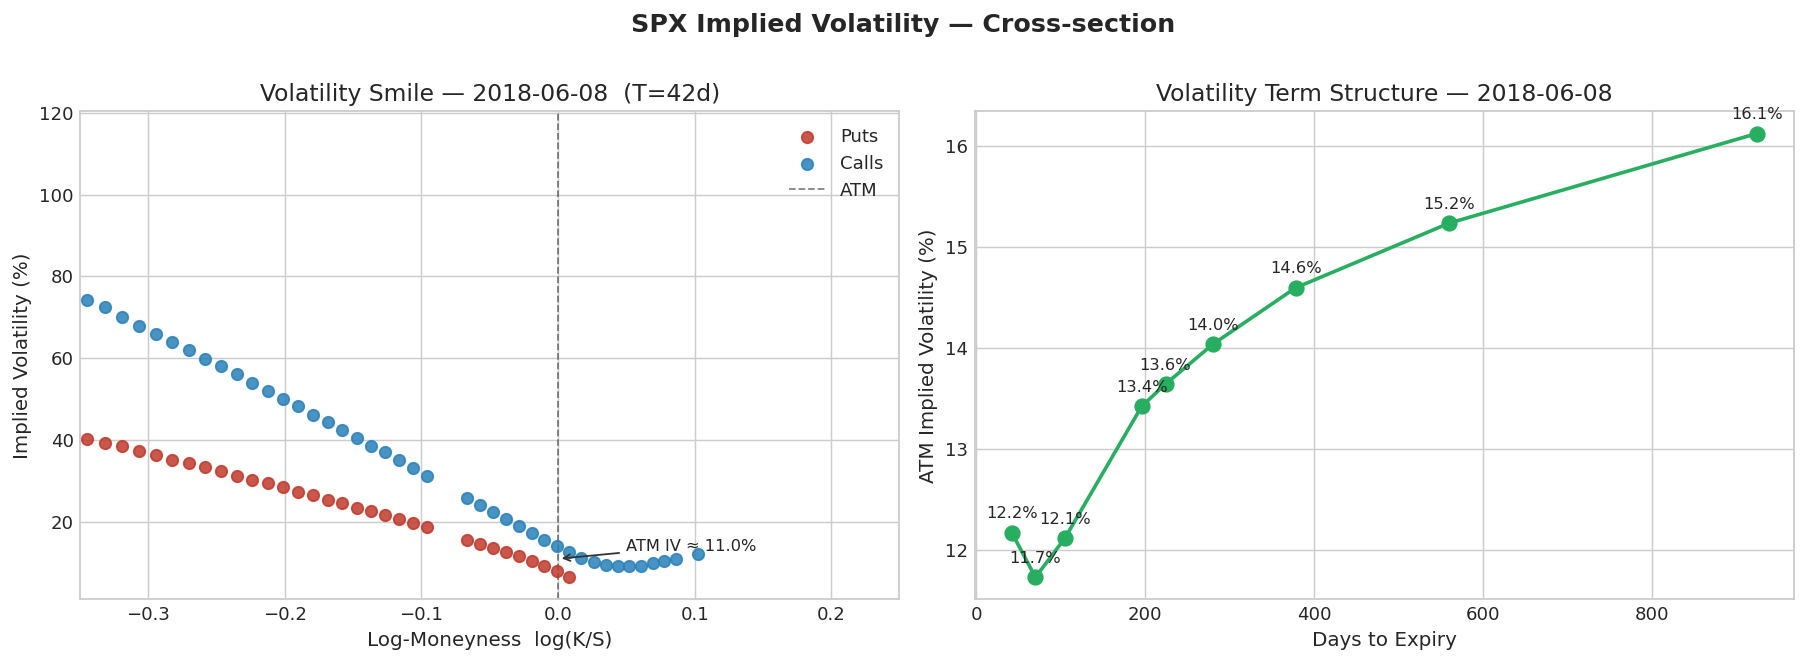

In [5]:
# ── Pick one representative date ──────────────────────────────────────────────
sample_date = pd.Timestamp('2018-06-08')   # change as needed
day_df = df[df['date'] == sample_date]

# Best expiry ~ TARGET_TENOR days
exp_options = day_df['exp_date'].unique()
best_exp    = exp_options[
    np.argmin(np.abs((pd.to_datetime(exp_options) - sample_date).days - TARGET_TENOR))
]
smile_df = day_df[day_df['exp_date'] == best_exp].sort_values('log_m')
T_actual = int((best_exp - sample_date).days)
print(f"Plotting smile for {sample_date.date()}  expiry={best_exp.date()}  T={T_actual}d")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Smile
ax = axes[0]
for opt_type, color, label in [('P','#c0392b','Puts'), ('C','#2980b9','Calls')]:
    sub = smile_df[smile_df['type'] == opt_type]
    ax.scatter(sub['log_m'], sub['iv']*100, color=color, s=40, alpha=0.85,
               label=label, zorder=3)
ax.axvline(0, color='#333', lw=1, ls='--', alpha=0.6, label='ATM')
atm_iv_val = smile_df[smile_df['log_m'].abs() < 0.01]['iv'].mean() * 100
ax.annotate(f'ATM IV ≈ {atm_iv_val:.1f}%', xy=(0, atm_iv_val),
            xytext=(0.05, atm_iv_val + 2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.set(xlabel='Log-Moneyness  log(K/S)', ylabel='Implied Volatility (%)',
       title=f'Volatility Smile — {sample_date.date()}  (T={T_actual}d)',
       xlim=(-0.35, 0.25))
ax.legend(fontsize=10)

# Right: Term structure of ATM IV
ts_rows = []
for exp in sorted(day_df['exp_date'].unique()):
    sub = day_df[(day_df['exp_date'] == exp) & (day_df['log_m'].abs() < 0.03)]
    if len(sub) > 0:
        ts_rows.append({'days': (exp - sample_date).days, 'atm_iv': sub['iv'].mean()*100})
ts = pd.DataFrame(ts_rows)
ax = axes[1]
ax.plot(ts['days'], ts['atm_iv'], 'o-', color='#27ae60', lw=2, ms=8)
for _, r in ts.iterrows():
    ax.annotate(f"{r['atm_iv']:.1f}%", (r['days'], r['atm_iv']),
                textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')
ax.set(xlabel='Days to Expiry', ylabel='ATM Implied Volatility (%)',
       title=f'Volatility Term Structure — {sample_date.date()}')

plt.suptitle('SPX Implied Volatility — Cross-section', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_smile_termstructure.png', dpi=150, bbox_inches='tight')
plt.show()


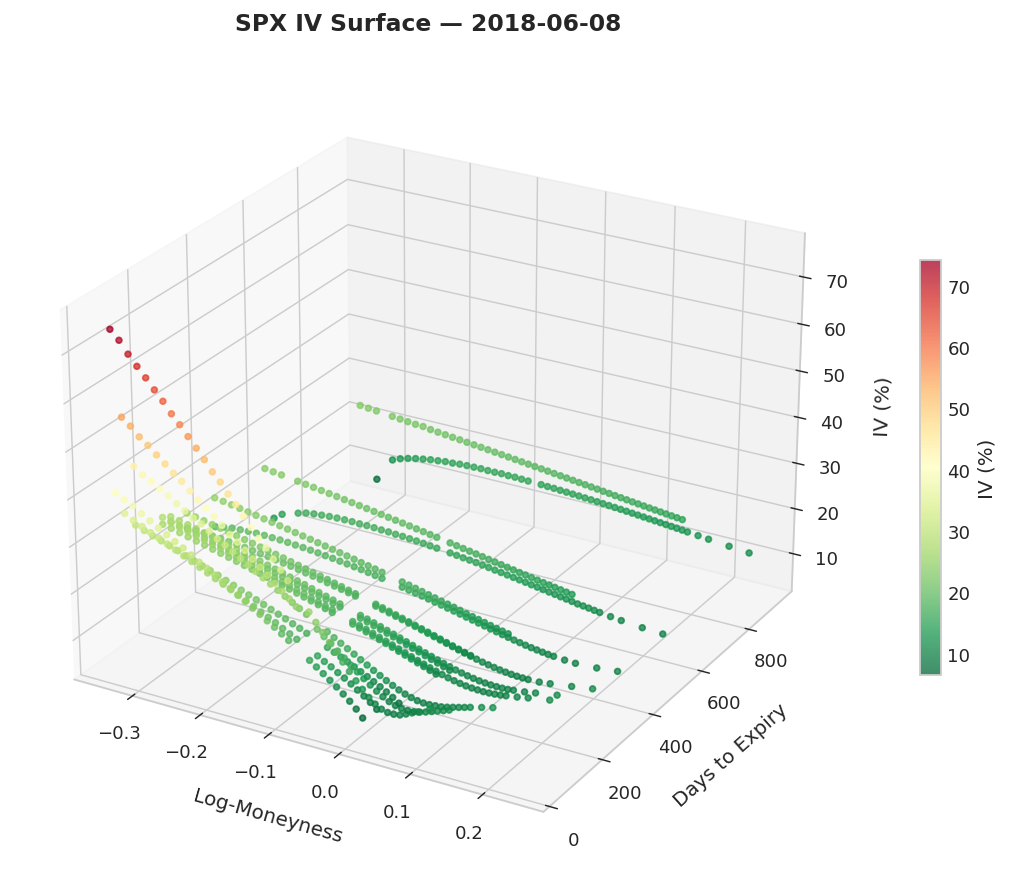

In [6]:
# ── 3-D volatility surface ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
surf_df = day_df[(day_df['log_m'] > -0.35) & (day_df['log_m'] < 0.25)]
sc = ax.scatter(surf_df['log_m'], surf_df['T']*365, surf_df['iv']*100,
                c=surf_df['iv']*100, cmap='RdYlGn_r', s=10, alpha=0.75)
ax.set_xlabel('Log-Moneyness', labelpad=8)
ax.set_ylabel('Days to Expiry', labelpad=8)
ax.set_zlabel('IV (%)', labelpad=8)
ax.set_title(f'SPX IV Surface — {sample_date.date()}', fontweight='bold', pad=12)
plt.colorbar(sc, ax=ax, shrink=0.5, label='IV (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.savefig('fig2_vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Daily time-series: ATM IV (ténor constant), skew, convexity

### 5.1 Problème du ténor variable

Une approche naïve consisterait à sélectionner, chaque jour, l'expiry la plus proche du
ténor cible (30 jours). Cela crée un $X_t$ **hétérogène** : l'option sélectionnée peut
avoir 42 jours de maturité un jour, 20 jours le suivant, avec des sauts discrets à chaque
*roll* d'expiry. Le ténor oscille continûment entre deux rolls, puis saute brusquement.
Comparer une IV à 42j un jour et à 20j le lendemain brise la cohérence de la série $X_t$.

### 5.2 Solution : interpolation à ténor constant

On encadre le ténor cible $\tau = 30$ jours entre les deux expiries disponibles
$T_1 \leq \tau < T_2$ et on interpole **en variance** (linéairement en $\sigma^2$,
pas en $\sigma$) :

$$\sigma_{\tau}^2 = \frac{T_2 - \tau}{T_2 - T_1}\,\sigma_{T_1}^2
                  + \frac{\tau - T_1}{T_2 - T_1}\,\sigma_{T_2}^2$$

$$\sigma_{\tau} = \sqrt{\sigma_{\tau}^2}$$

L'interpolation se fait en variance et non en volatilité parce que la variance est
additive dans le temps (propriété de l'intégrale de la variance instantanée sous
Black-Scholes) : $\sigma^2 T$ est une espérance de variance intégrée, et c'est cette
quantité qui varie linéairement avec $T$. C'est exactement la méthodologie utilisée
par le **CBOE pour calculer le VIX**.

### 5.3 Métriques extraites

Les mêmes trois métriques sont calculées pour chacune des deux expiries encadrantes,
puis interpolées séparément :

$$\text{Skew}_t = \overline{\text{IV}}_{\text{put wing}} - \overline{\text{IV}}_{\text{call wing}}$$

$$\text{Convexity}_t = \frac{\overline{\text{IV}}_{\text{put wing}} + \overline{\text{IV}}_{\text{call wing}}}{2} - \text{ATM\_IV}_t$$


In [ ]:
def _slice_metrics(t_df, wing_lo, wing_hi_p, wing_lo_c, wing_hi):
    """ATM IV, put-wing IV, call-wing IV for a single expiry slice."""
    if len(t_df) < 3:
        return np.nan, np.nan, np.nan
    atm_iv = t_df.loc[t_df['log_m'].abs().idxmin(), 'iv']
    p_wing = t_df[(t_df['log_m'] > wing_lo)  & (t_df['log_m'] < wing_hi_p) & (t_df['type']=='P')]
    c_wing = t_df[(t_df['log_m'] > wing_lo_c) & (t_df['log_m'] < wing_hi)  & (t_df['type']=='C')]
    iv_p   = p_wing['iv'].mean() if len(p_wing) > 0 else np.nan
    iv_c   = c_wing['iv'].mean() if len(c_wing) > 0 else np.nan
    return atm_iv, iv_p, iv_c


def _interp_var(iv1, iv2, T1, T2, tau):
    """Linear interpolation in variance space between tenors T1 < tau <= T2."""
    if T1 == T2:
        return iv1
    w1  = (T2 - tau) / (T2 - T1)
    w2  = (tau - T1) / (T2 - T1)
    var = w1 * iv1**2 + w2 * iv2**2
    return np.sqrt(max(var, 0.0))


def extract_daily_metrics(df, target_tenor=TARGET_TENOR,
                          wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                          wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH):
    """
    Extract ATM IV, skew, convexity per trading day using constant-maturity
    interpolation: variance-weighted blend of the two expiries bracketing
    target_tenor days (same methodology as the CBOE VIX).
    """
    rows = []
    for date, day in df.groupby('date'):
        exps   = np.array(sorted(day['exp_date'].unique()))
        tenors = np.array([(pd.Timestamp(e) - date).days for e in exps])

        below = tenors[tenors <= target_tenor]
        above = tenors[tenors >  target_tenor]

        if len(below) == 0 or len(above) == 0:
            # Edge case: target is outside available range → use closest expiry
            best_exp = exps[np.argmin(np.abs(tenors - target_tenor))]
            t_df     = day[day['exp_date'] == best_exp].sort_values('log_m')
            atm_iv, iv_p, iv_c = _slice_metrics(t_df, wing_lo, wing_hi_p, wing_lo_c, wing_hi)
        else:
            T1   = int(below[-1])   # largest tenor <= target
            T2   = int(above[0])    # smallest tenor > target
            exp1 = exps[tenors == T1][0]
            exp2 = exps[tenors == T2][0]

            t_df1 = day[day['exp_date'] == exp1].sort_values('log_m')
            t_df2 = day[day['exp_date'] == exp2].sort_values('log_m')

            atm1, ivp1, ivc1 = _slice_metrics(t_df1, wing_lo, wing_hi_p, wing_lo_c, wing_hi)
            atm2, ivp2, ivc2 = _slice_metrics(t_df2, wing_lo, wing_hi_p, wing_lo_c, wing_hi)

            if np.isnan(atm1) or np.isnan(atm2):
                atm_iv = atm1 if not np.isnan(atm1) else atm2
                iv_p   = ivp1 if not np.isnan(ivp1) else ivp2
                iv_c   = ivc1 if not np.isnan(ivc1) else ivc2
            else:
                atm_iv = _interp_var(atm1, atm2, T1, T2, target_tenor)
                iv_p   = _interp_var(ivp1, ivp2, T1, T2, target_tenor) \
                         if not (np.isnan(ivp1) or np.isnan(ivp2)) else np.nan
                iv_c   = _interp_var(ivc1, ivc2, T1, T2, target_tenor) \
                         if not (np.isnan(ivc1) or np.isnan(ivc2)) else np.nan

        rows.append({
            'date'        : date,
            'atm_iv'      : atm_iv,
            'skew'        : iv_p - iv_c if not (np.isnan(iv_p) or np.isnan(iv_c)) else np.nan,
            'convexity'   : (iv_p + iv_c) / 2 - atm_iv
                            if not (np.isnan(iv_p) or np.isnan(iv_c)) else np.nan,
            'iv_put_wing' : iv_p,
            'iv_call_wing': iv_c,
        })

    metrics = pd.DataFrame(rows).set_index('date').sort_index()
    print(f"✓ Daily metrics: {len(metrics)} trading days  "
          f"(constant-maturity {target_tenor}d interpolation)")
    return metrics


metrics = extract_daily_metrics(df)
metrics.head()


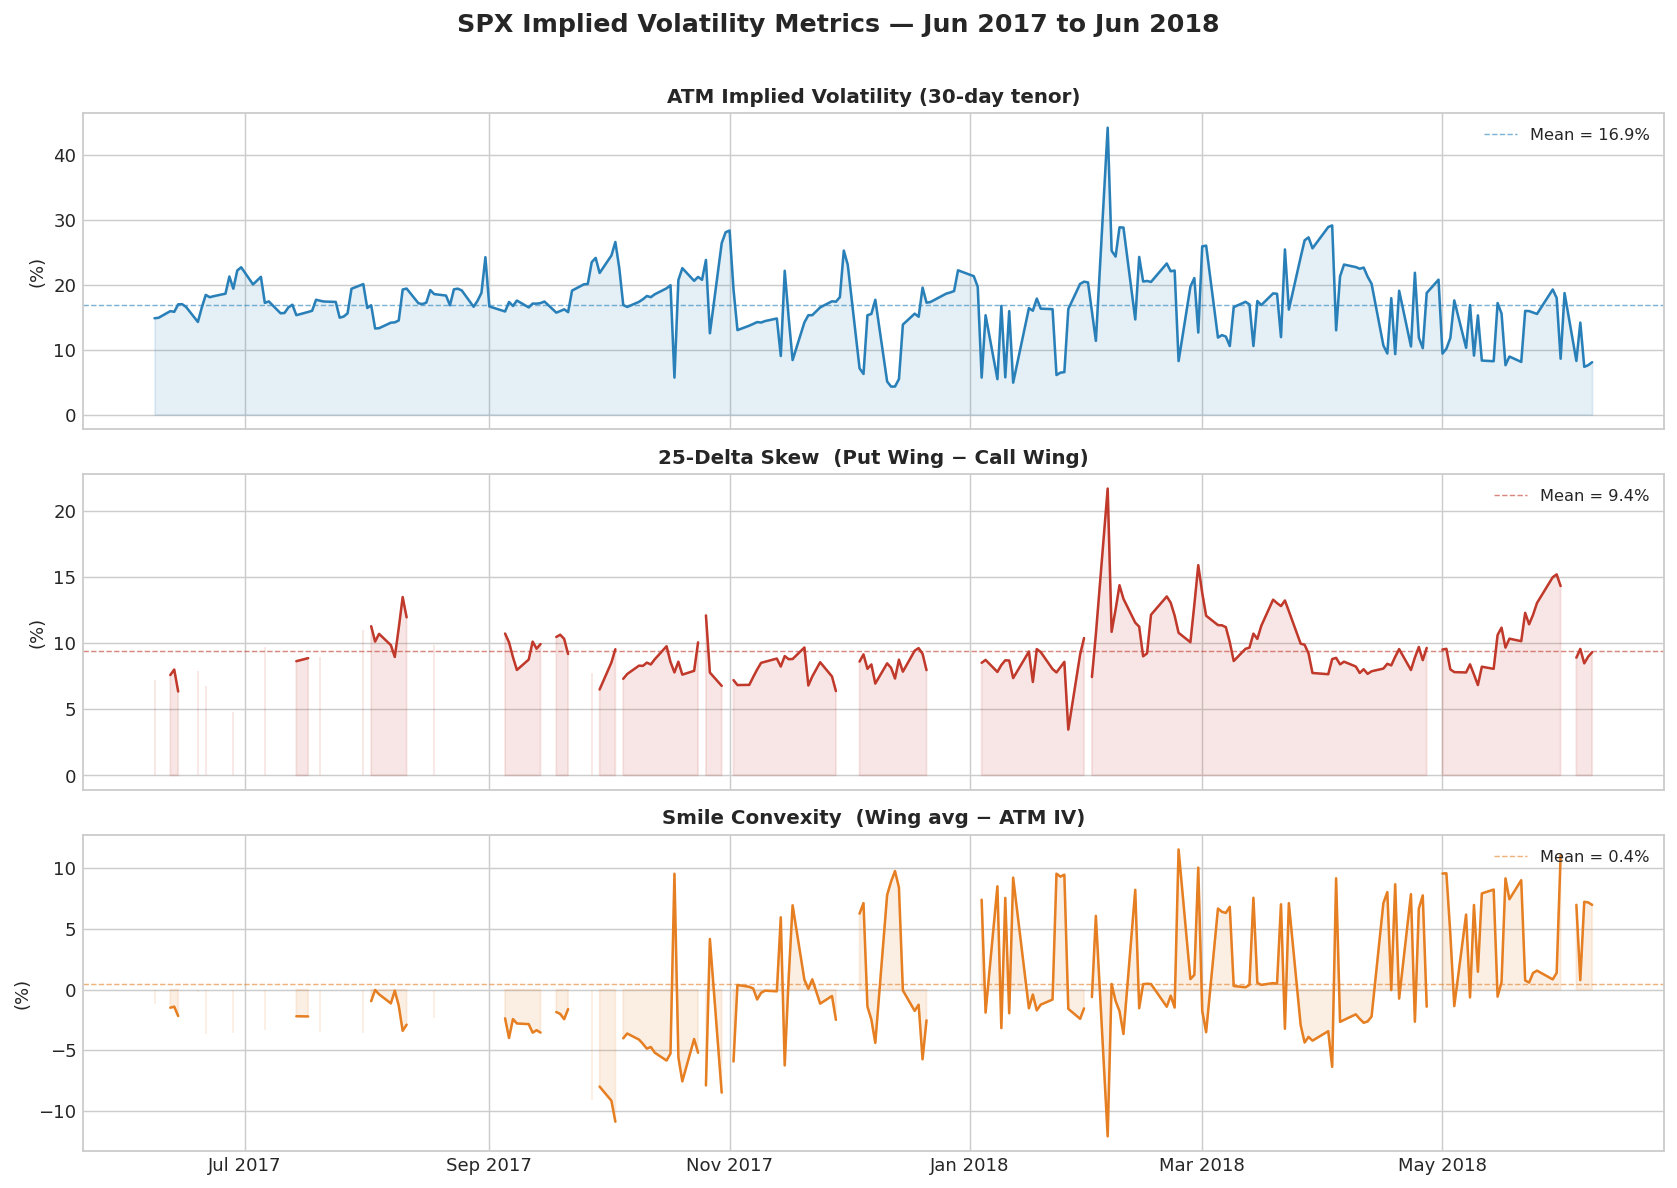

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['#2980b9', '#c0392b', '#e67e22']
titles = ['ATM Implied Volatility (30-day tenor)',
          '25-Delta Skew  (Put Wing − Call Wing)',
          'Smile Convexity  (Wing avg − ATM IV)']
cols   = ['atm_iv', 'skew', 'convexity']

for ax, col, color, title in zip(axes, cols, colors, titles):
    y = metrics[col] * 100
    ax.plot(metrics.index, y, color=color, lw=1.4)
    ax.fill_between(metrics.index, y, alpha=0.12, color=color)
    ax.axhline(y.mean(), color=color, lw=0.8, ls='--', alpha=0.6,
               label=f'Mean = {y.mean():.1f}%')
    ax.set_ylabel('(%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('SPX Implied Volatility Metrics — Jun 2017 to Jun 2018',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_iv_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Realized volatility & Variance Risk Premium

**Realized volatility** (historical) over a rolling 21-day window:

$$RV_t = \sqrt{252} \cdot \hat\sigma\left(r_{t-20},\ldots,r_{t}\right), \quad r_t = \ln\frac{S_t}{S_{t-1}}$$

**Forward realized volatility** (what we want to predict):

$$RV^{\text{fwd}}_t = \sqrt{252} \cdot \hat\sigma\left(r_{t+1},\ldots,r_{t+21}\right)$$

**Variance Risk Premium**:

$$\text{VRP}_t = IV_t - RV_t \quad (\text{typically positive → investors overpay for vol protection})$$


=== Variance Risk Premium ===
Mean VRP (IV − RV) : +5.84%
Std  VRP           :  8.66%
% positive (IV>RV) :  73.9%
Sample size        :  211 days


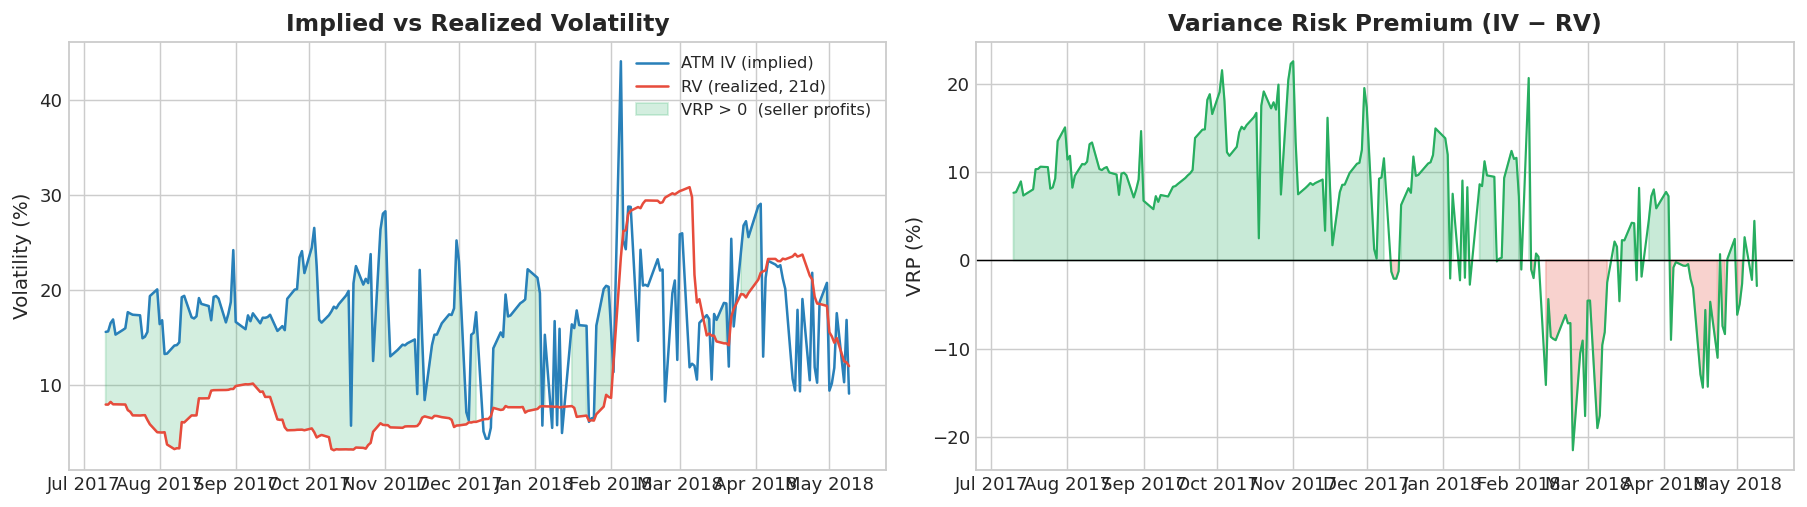

In [9]:
# ── Spot price from the dataset itself (put-call parity median per day) ────────
spot_ts = df.groupby('date')['spot'].median().sort_index()

# Add extra buffer around the sample for the rolling windows
log_ret = np.log(spot_ts / spot_ts.shift(1))

rv_past    = log_ret.rolling(RV_WINDOW).std() * np.sqrt(252)
rv_forward = log_ret.shift(-RV_WINDOW).rolling(RV_WINDOW).std() * np.sqrt(252)

# Merge into regression dataframe
reg = metrics.copy()
reg['rv_past']    = rv_past.reindex(reg.index)
reg['rv_forward'] = rv_forward.reindex(reg.index)
reg['vrp']        = reg['atm_iv'] - reg['rv_past']
reg = reg.dropna(subset=['atm_iv', 'rv_past', 'rv_forward'])

print("=== Variance Risk Premium ===")
print(f"Mean VRP (IV − RV) : {reg['vrp'].mean()*100:+.2f}%")
print(f"Std  VRP           :  {reg['vrp'].std()*100:.2f}%")
print(f"% positive (IV>RV) :  {(reg['vrp']>0).mean()*100:.1f}%")
print(f"Sample size        :  {len(reg)} days")

# ── Plot IV vs RV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(reg.index, reg['atm_iv']*100, color='#2980b9', lw=1.4, label='ATM IV (implied)')
ax.plot(reg.index, reg['rv_past']*100, color='#e74c3c', lw=1.4, label='RV (realized, 21d)')
ax.fill_between(reg.index, reg['atm_iv']*100, reg['rv_past']*100,
                where=reg['atm_iv'] > reg['rv_past'], alpha=0.2, color='#27ae60',
                label='VRP > 0  (seller profits)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Volatility (%)')
ax.set_title('Implied vs Realized Volatility', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(reg.index, reg['vrp']*100, color='#27ae60', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']>0, alpha=0.25, color='#27ae60')
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']<=0, alpha=0.25, color='#e74c3c')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('VRP (%)')
ax.set_title('Variance Risk Premium (IV − RV)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_vrp.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · OLS regression — implementation

We implement OLS from scratch (as expected in an econometrics course):

$$\hat\beta = (X'X)^{-1}X'y, \qquad \widehat{\text{Var}}(\hat\beta) = s^2 (X'X)^{-1}, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}$$


In [10]:
def ols(y, X_df, add_const=True):
    """
    OLS estimator with full output.
    Parameters
    ----------
    y      : array-like, dependent variable
    X_df   : DataFrame or array, regressors (without constant)
    Returns dict with beta, se, t_stat, p_value, r2, adj_r2, resid
    """
    from scipy.stats import t as t_dist

    y = np.asarray(y, dtype=float)
    X = np.asarray(X_df, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if add_const:
        X = np.column_stack([np.ones(len(X)), X])

    # Drop NaN rows
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n, k = X.shape

    XtX_inv = np.linalg.inv(X.T @ X)
    beta    = XtX_inv @ X.T @ y
    y_hat   = X @ beta
    resid   = y - y_hat
    s2      = (resid @ resid) / (n - k)

    se      = np.sqrt(np.diag(s2 * XtX_inv))
    t_stat  = beta / se
    p_val   = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) @ (y - y.mean()))
    r2     = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)

    return dict(beta=beta, se=se, t_stat=t_stat, p_val=p_val,
                r2=r2, adj_r2=adj_r2, resid=resid, n=n, k=k)


def reg_table(result, names):
    """Pretty-print regression results."""
    print(f"\n{'─'*62}")
    print(f"{'Variable':<22} {'Coef':>9} {'SE':>9} {'t':>8}  {'p':>8}")
    print(f"{'─'*62}")
    for nm, b, se, t, p in zip(names, result['beta'], result['se'],
                                result['t_stat'], result['p_val']):
        stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        print(f"{nm:<22} {b:>9.4f} {se:>9.4f} {t:>8.3f}  {p:>8.4f} {stars}")
    print(f"{'─'*62}")
    print(f"{'R²':<22} {result['r2']:>9.4f}")
    print(f"{'Adj. R²':<22} {result['adj_r2']:>9.4f}")
    print(f"{'N':<22} {result['n']:>9}")
    print(f"{'─'*62}")
    print("Significance: * p<0.05  ** p<0.01  *** p<0.001")

print("✓ OLS functions defined")


✓ OLS functions defined


## 8 · Regression analysis

### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$

### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$


In [11]:
y = reg['rv_forward']

print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])

print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1372    0.0176    7.805    0.0000 ***
ATM_IV                   -0.1096    0.0969   -1.131    0.2593 
──────────────────────────────────────────────────────────────
R²                        0.0061
Adj. R²                   0.0013
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001

══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                

## 9 · Fixed Effects, Random Effects & Hausman Test

### 9.1 Panel structure

The data has a natural panel structure:
- **Entity** $i$ : tenor bucket (short: 0–60d, medium: 60–180d, long: >180d)
- **Time** $t$ : trading date
- 3 entities × 211 dates = 633 observations

Different tenor buckets have systematically different IV levels (term structure effect).
This unobserved heterogeneity biases pooled OLS — panel estimators control for it.

### 9.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_{t} = \alpha_i + \beta_1 IV_{it} + \beta_2 \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs all time-invariant characteristics of each tenor bucket.
Identification comes from **within-entity deviations** (demeaning):

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \quad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

Then OLS on the demeaned variables. The constant and all between-entity information are removed.

### 9.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0, \sigma^2_\alpha)$, **uncorrelated with regressors**.
Uses quasi-demeaning with parameter $\theta$:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T \cdot \sigma^2_\alpha}}$$

$$\tilde{y}_{it} = y_{it} - \theta\bar{y}_i$$

- $\theta \to 1$: RE $\to$ FE (entity effects dominate)
- $\theta \to 0$: RE $\to$ pooled OLS (no entity effects)

More efficient than FE if the RE assumption holds, because it uses both within **and** between variation.

### 9.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad (\text{RE consistent})$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- Reject $H_0$ → entity effects correlated with regressors → **use FE**
- Cannot reject $H_0$ → RE is consistent and more efficient → **prefer RE**


In [ ]:
# ── Panel construction ────────────────────────────────────────────────────────
df['tenor_bucket'] = pd.cut(df['T']*365,
                             bins=[0, 60, 180, 9999],
                             labels=['short', 'medium', 'long'])

def _panel_metrics(g):
    atm_iv = g[g['log_m'].abs() < 0.03]['iv'].mean()
    p_wing = g[(g['log_m'] > WING_LOW)  & (g['log_m'] < WING_HIGH_PUT) & (g['type']=='P')]['iv'].mean()
    c_wing = g[(g['log_m'] > WING_LOW_CALL) & (g['log_m'] < WING_HIGH) & (g['type']=='C')]['iv'].mean()
    conv   = (p_wing + c_wing) / 2 - atm_iv if not (np.isnan(p_wing) or np.isnan(c_wing)) else np.nan
    return pd.Series({'atm_iv': atm_iv, 'convexity': conv})

panel_agg = (df.groupby(['date', 'tenor_bucket'])
               .apply(_panel_metrics, include_groups=False)
               .reset_index())
panel_agg = panel_agg.merge(reg[['rv_forward']].reset_index(), on='date', how='left').dropna()
print(f"Panel: {len(panel_agg)} obs  "
      f"({panel_agg['date'].nunique()} dates × {panel_agg['tenor_bucket'].nunique()} buckets)")


# ── Fixed Effects (within estimator) ──────────────────────────────────────────
def within_estimator(panel, y_col, x_cols, entity_col):
    data = panel[[y_col] + x_cols + [entity_col]].dropna().copy()
    for col in [y_col] + x_cols:
        gm = data.groupby(entity_col)[col].transform('mean')
        data[col + '_dm'] = data[col] - gm
    y_dm = data[y_col + '_dm'].values
    X_dm = data[[c + '_dm' for c in x_cols]].values
    return ols(y_dm, X_dm, add_const=False)


# ── Random Effects (GLS via quasi-demeaning) ───────────────────────────────────
def re_estimator(panel, y_col, x_cols, entity_col):
    data = panel[[y_col] + x_cols + [entity_col]].dropna().copy()
    N = data[entity_col].nunique()
    T = data.groupby(entity_col).size().mean()
    K = len(x_cols)

    # σ²_ε from within residuals
    fe     = within_estimator(data, y_col, x_cols, entity_col)
    s2_e   = np.sum(fe['resid']**2) / (len(fe['resid']) - N - K)

    # σ²_α from between estimator
    means  = data.groupby(entity_col)[[y_col] + x_cols].mean()
    be     = ols(means[y_col].values, means[x_cols].values)
    s2_b   = np.sum(be['resid']**2) / max(N - K - 1, 1)
    s2_a   = max(0.0, s2_b - s2_e / T)

    # Quasi-demeaning
    theta  = 1.0 - np.sqrt(s2_e / (s2_e + T * s2_a)) if s2_a > 0 else 0.0
    for col in [y_col] + x_cols:
        gm = data.groupby(entity_col)[col].transform('mean')
        data[col + '_qd'] = data[col] - theta * gm

    y_qd   = data[y_col + '_qd'].values
    X_qd   = data[[c + '_qd' for c in x_cols]].values
    result = ols(y_qd, X_qd)
    result.update({'theta': theta, 'sigma2_e': s2_e, 'sigma2_a': s2_a})
    return result


# ── Hausman test ───────────────────────────────────────────────────────────────
def hausman_test(fe_res, re_res):
    b_fe   = fe_res['beta']
    b_re   = re_res['beta'][1:]          # drop RE constant
    diff   = b_fe - b_re
    V_diff = np.diag(fe_res['se']**2) - np.diag(re_res['se'][1:]**2)
    try:
        H = float(diff @ np.linalg.inv(V_diff) @ diff)
    except np.linalg.LinAlgError:
        H = float(diff @ np.linalg.pinv(V_diff) @ diff)
    p = 1 - stats.chi2.cdf(H, df=len(b_fe))
    return H, p


# ── Run ────────────────────────────────────────────────────────────────────────
from scipy import stats
x_cols = ['atm_iv', 'convexity']

print('\n' + '\u2550'*62)
print('FIXED EFFECTS \u2014 RV_fwd ~ ATM_IV + Convexity')
print('\u2550'*62)
fe_res = within_estimator(panel_agg, 'rv_forward', x_cols, 'tenor_bucket')
reg_table(fe_res, x_cols)

print('\n' + '\u2550'*62)
print('RANDOM EFFECTS \u2014 RV_fwd ~ ATM_IV + Convexity')
print('\u2550'*62)
re_res = re_estimator(panel_agg, 'rv_forward', x_cols, 'tenor_bucket')
reg_table(re_res, ['Const'] + x_cols)
print(f"  \u03b8 (quasi-demeaning) = {re_res['theta']:.4f}")
print(f"  \u03c3\u00b2_\u03b5 = {re_res['sigma2_e']:.6f}   "
      f"\u03c3\u00b2_\u03b1 = {re_res['sigma2_a']:.6f}")

print('\n' + '\u2550'*62)
print('HAUSMAN TEST')
print('\u2550'*62)
H_stat, H_p = hausman_test(fe_res, re_res)
print(f"  H statistic = {H_stat:.4f}")
print(f"  p-value     = {H_p:.4f}   df = {len(x_cols)}")
print(f"  \u2192 {'Use FE: reject RE consistency' if H_p < 0.05 else 'RE preferred: cannot reject H0'}")


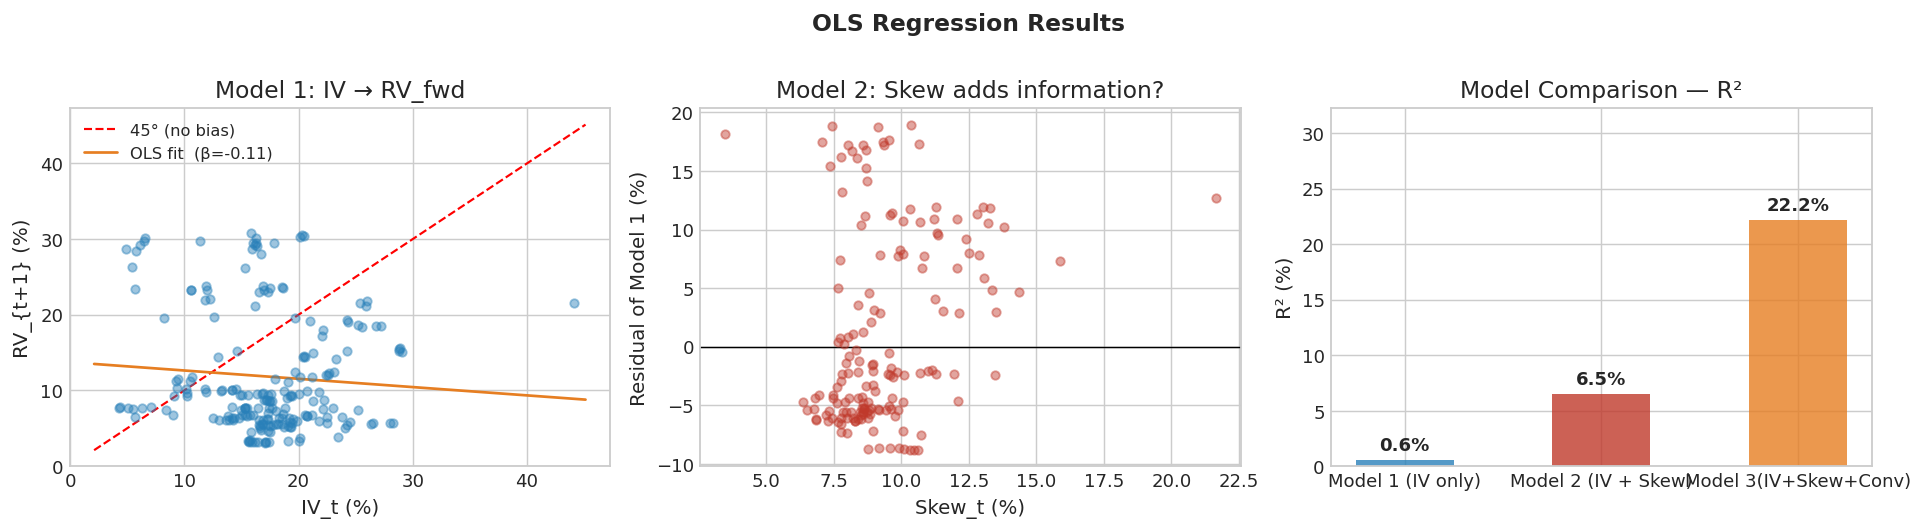

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Scatter 1: IV vs RV_fwd ────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(reg['atm_iv']*100, reg['rv_forward']*100,
           alpha=0.45, s=22, color='#2980b9', zorder=3)
lim = [min(reg['atm_iv'].min(), reg['rv_forward'].min())*100 - 1,
       max(reg['atm_iv'].max(), reg['rv_forward'].max())*100 + 1]
ax.plot(lim, lim, 'r--', lw=1.2, label='45° (no bias)')
# OLS fit line
x_fit = np.linspace(*lim, 100)
b = r1['beta']
ax.plot(x_fit, (b[0] + b[1]*x_fit/100)*100, color='#e67e22', lw=1.5,
        label=f'OLS fit  (β={b[1]:.2f})')
ax.set(xlabel='IV_t (%)', ylabel='RV_{t+1} (%)',
       title='Model 1: IV → RV_fwd')
ax.legend(fontsize=9)

# ── Scatter 2: Skew vs residuals of Model 1 ───────────────────────────────────
ax = axes[1]
valid_mask = ~(np.isnan(reg['atm_iv']) | np.isnan(reg['skew']) | np.isnan(reg['rv_forward']))
resid1 = reg.loc[valid_mask, 'rv_forward'].values -          (r1['beta'][0] + r1['beta'][1] * reg.loc[valid_mask, 'atm_iv'].values)
ax.scatter(reg.loc[valid_mask, 'skew']*100, resid1*100,
           alpha=0.45, s=22, color='#c0392b', zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set(xlabel='Skew_t (%)', ylabel='Residual of Model 1 (%)',
       title='Model 2: Skew adds information?')

# ── Plot 3: R² comparison ──────────────────────────────────────────────────────
ax = axes[2]
models = ['Model 1 (IV only)', 'Model 2 (IV + Skew)', 'Model 3(IV+Skew+Conv)']
r2s    = [r1['r2'], r2['r2'], r3['r2']]
bars   = ax.bar(models, [v*100 for v in r2s],
                color=['#2980b9', '#c0392b', '#e67e22'], alpha=0.8, width=0.5)
for bar, r2_val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{r2_val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set(ylabel='R² (%)', title='Model Comparison — R²',
       ylim=[0, max(r2s)*100 + 10])

plt.suptitle('OLS Regression Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_regression.png', dpi=150, bbox_inches='tight')
plt.show()


## 10 · Residual diagnostics

Standard OLS assumptions to verify:
1. **Linearity**: residuals vs fitted should show no pattern
2. **Homoscedasticity**: residual variance should be constant
3. **Normality**: Jarque-Bera test
4. **No autocorrelation**: Durbin-Watson statistic  
   $DW = \frac{\sum_{t=2}^n(\hat\varepsilon_t - \hat\varepsilon_{t-1})^2}{\sum_{t=1}^n \hat\varepsilon_t^2}$ — close to 2 is ideal


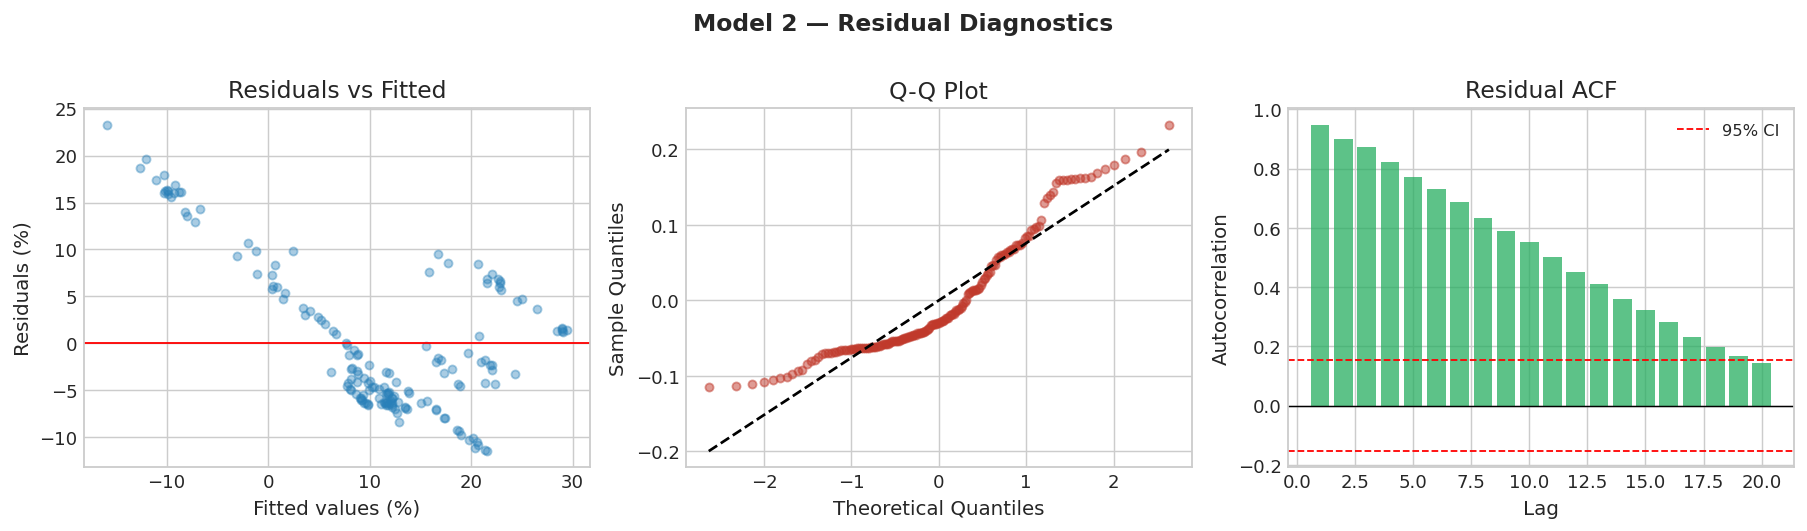

Jarque-Bera test : stat=24.318,  p=0.0000  ← reject normality
Durbin-Watson    : 0.1024  ← autocorrelation present


In [17]:
from scipy import stats

resid = r2['resid']
y_hat_m2 = reg['rv_forward'].dropna().values[:len(resid)] - resid  # approximate

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals vs fitted
ax = axes[0]
ax.scatter(y_hat_m2*100, resid*100, alpha=0.4, s=20, color='#2980b9')
ax.axhline(0, color='red', lw=1)
ax.set(xlabel='Fitted values (%)', ylabel='Residuals (%)',
       title='Residuals vs Fitted')

# QQ plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=20, color='#c0392b')
x_line = np.array([osm.min(), osm.max()])
ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5)
ax.set(xlabel='Theoretical Quantiles', ylabel='Sample Quantiles', title='Q-Q Plot')

# Residual autocorrelation (ACF-like)
ax = axes[2]
lags = range(1, 21)
acfs = [np.corrcoef(resid[:-lag], resid[lag:])[0,1] for lag in lags]
ax.bar(lags, acfs, color='#27ae60', alpha=0.75)
ax.axhline(0, color='black', lw=0.8)
ax.axhline( 1.96/np.sqrt(len(resid)), color='red', lw=1, ls='--', label='95% CI')
ax.axhline(-1.96/np.sqrt(len(resid)), color='red', lw=1, ls='--')
ax.set(xlabel='Lag', ylabel='Autocorrelation', title='Residual ACF')
ax.legend(fontsize=9)

plt.suptitle('Model 2 — Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical tests ──────────────────────────────────────────────────────────
jb_stat, jb_p = stats.jarque_bera(resid)
dw = np.sum(np.diff(resid)**2) / np.sum(resid**2)
print(f"Jarque-Bera test : stat={jb_stat:.3f},  p={jb_p:.4f}  {'← reject normality' if jb_p<0.05 else '← cannot reject normality'}")
print(f"Durbin-Watson    : {dw:.4f}  {'← autocorrelation present' if abs(dw-2)>0.5 else '← no strong autocorrelation'}")


## 11 · Summary & next steps

### Key results so far (Chapter 1)

| | Model 1 | Model 2 | Model 3 |
|---|---|---|---|
| **Regressors** | IV | IV + Skew | IV + Skew + Conv |
| **R²** | *run to see* | *run to see* | *run to see* |
| **β(IV)** | < 1 (expected) | — | — |
| **β(Skew)** | — | sign & sig? | — |

### Interpretation of β(IV) < 1
A slope less than 1 on IV in the Mincer-Zarnowitz regression is the **econometric fingerprint of the VRP**.  
It means that when IV is high, the market is over-estimating future volatility by a factor of $(1 - \beta_1)$.

### Next chapters to code
- **Chapter 2** · ARMA/GARCH on the ATM IV time series
- **Chapter 3** · VAR(p) between ATM IV, skew, and S&P 500 returns
- **Chapter 4** · Cointegration test: IV vs RV (are they bound together long-run?)
- **Chapter 5** · PCA on the full IV surface (factor structure)
